In [1]:
#loading python classes and packages
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D
from keras.models import Sequential, load_model, Model
import pickle
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Using TensorFlow backend.
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [18]:
#global variable definition for images and label storage
X = []
Y = []
path = "Dataset"
labels = []

In [19]:
#load different Areas labels
for root, dirs, directory in os.walk(path):
    for j in range(len(directory)):
        name = os.path.basename(root)
        if name not in labels:
            labels.append(name.strip())
print("Different Areas found in SAR images : "+str(labels))            

Different Areas found in SAR images : ['agri', 'barrenland', 'building', 'flooded', 'forest', 'grassland', 'mountains', 'sea', 'street', 'urban']


In [8]:
#function to get integer id for given sar image area
def getLabel(name):
    index = -1
    for i in range(len(labels)):
        if labels[i] == name:
            index = i
            break
    return index

In [9]:
#function to load and process SAR images
if os.path.exists('model/X.npy'): #if images already processed the laod it
    X = np.load('model/X.npy')
    Y = np.load('model/Y.npy')
else: #if not processed then read each image and process them
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)):
            if 'Thumbs.db' not in directory[j]:
                img = cv2.imread(root+"/"+directory[j])#read each image and extract features and add to X and Y array for training
                img = cv2.resize(img, (32, 32))
                label = 0 #for fake image label will be 0
                name = os.path.basename(root)
                label = getLabel(name)
                X.append(img)
                Y.append(label)
print("SAR Images Loading Completed")
print("Total images found in dataset = "+str(X.shape[0]))

SAR Images Loading Completed
Total images found in dataset = 19600


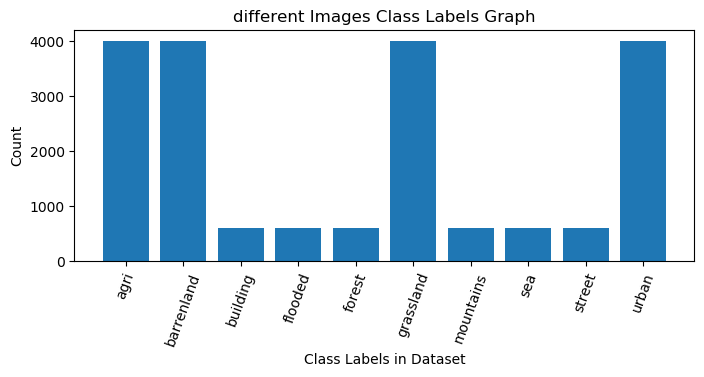

In [11]:
#visualizing class labels count found in dataset
names, count = np.unique(Y, return_counts = True)
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (8, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Class Labels in Dataset")
plt.ylabel("Count")
plt.xticks(rotation=70)
plt.title("different Images Class Labels Graph")
plt.show()

In [12]:
#dataset processing such as shuffling and normalizing and this processing will be done on classification images and report generation images
X = X.astype('float32')
X = X/255
indices = np.arange(X.shape[0])
np.random.shuffle(indices) #shuffle images
X = X[indices]
Y = Y[indices]
Y = to_categorical(Y)
print("Images Shuffling & Normalization completed")

Images Shuffling & Normalization completed


In [13]:
#splitting images data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2) #split dataset into train and test
print("Dataset Train & Test Split Details")
print("80% images files used to train algorithms : "+str(X_train.shape[0]))
print("20% images files used to test algorithms : "+str(X_test.shape[0]))

Dataset Train & Test Split Details
80% images files used to train algorithms : 15680
20% images files used to test algorithms : 3920


In [20]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [21]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g")
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.show()  

CNN2D Accuracy  : 96.14795918367346
CNN2D Precision : 93.7316438579027
CNN2D Recall    : 91.93202514926844
CNN2D FSCORE    : 92.36496960215386


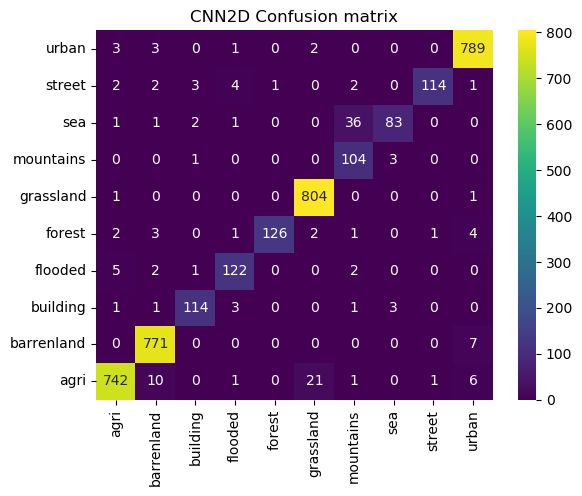

In [22]:
#defining CNN2D algorithm with different layers and neurons to optimize image features
cnn_model = Sequential()
#defining CNN layer with 32 neurons of 3 X 3 matrix to filter features using 32 neurons
cnn_model.add(Convolution2D(32, (3 , 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
#max layer to collect relevant features from CNN layer
cnn_model.add(MaxPooling2D(pool_size = (2, 2)))
#defining another layer to further optimize features
cnn_model.add(Convolution2D(32, (3, 3), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (2, 2)))
cnn_model.add(Flatten())
#defining output prediction layer
cnn_model.add(Dense(units = 256, activation = 'relu'))
cnn_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compiling, training and loading model
cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn_model.fit(X_train, y_train, batch_size = 32, epochs = 15, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn_model.load_weights("model/cnn_weights.hdf5")
#perform prediction on test images
predict = cnn_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("CNN2D", y_test1, predict)

In [29]:
#define and load LIME object
# Create LIME image explainer
explainer = lime_image.LimeImageExplainer()
print("Lime model loaded")

Lime model loaded


In [36]:
#function to classify image and then employ LIME to explain which features of image make model to predict paricular label
def predictRoute(image_path):
    image = cv2.imread(image_path)
    img = cv2.resize(image, (32,32))
    im2arr = np.array(img)
    im2arr = im2arr.reshape(1,32,32,3)
    img = np.asarray(im2arr)
    img = img.astype('float32')
    img = img/255
    predict = cnn_model.predict(img)
    predict = np.argmax(predict)
    status = labels[predict]
    # Generate Lime explanation
    explanation = explainer.explain_instance(img[0], cnn_model.predict)
    # Visualize the explanation
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
    lime_marking = mark_boundaries(temp / 2 + 0.5, mask)
    lime_marking = cv2.resize(lime_marking, (150, 150), interpolation=cv2.INTER_LANCZOS4)
    image = cv2.imread(image_path)
    image = cv2.resize(image, (150, 150))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    cv2.putText(image, status, (10, 25),  cv2.FONT_HERSHEY_SIMPLEX,0.6, (0, 0, 255), 2)
    f, axarr = plt.subplots(1,2, figsize=(10,5)) 
    axarr[0].imshow(image)
    axarr[0].title.set_text(status+" a head in route")
    axarr[1].imshow(lime_marking)
    axarr[1].title.set_text('Lime Explanation Image')
    plt.axis('off')
    plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

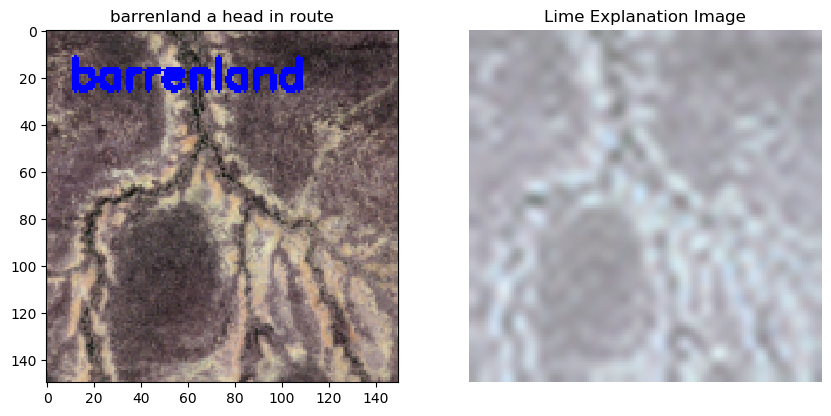

In [37]:
#call this function with image to predict route
predictRoute("testImages/1.png")

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


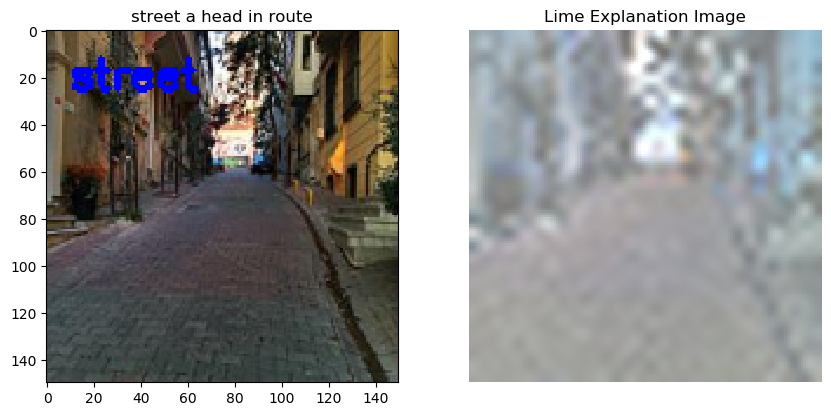

In [39]:
#call this function with image to predict route
predictRoute("testImages/01.jpg")

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


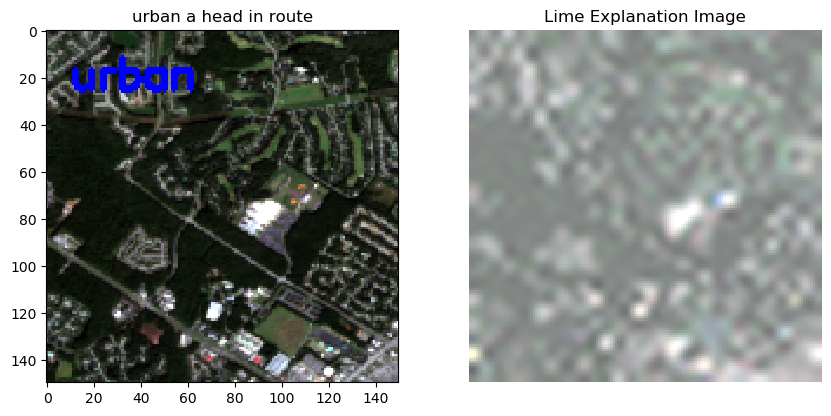

In [40]:
#call this function with image to predict route
predictRoute("testImages/02.png")

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


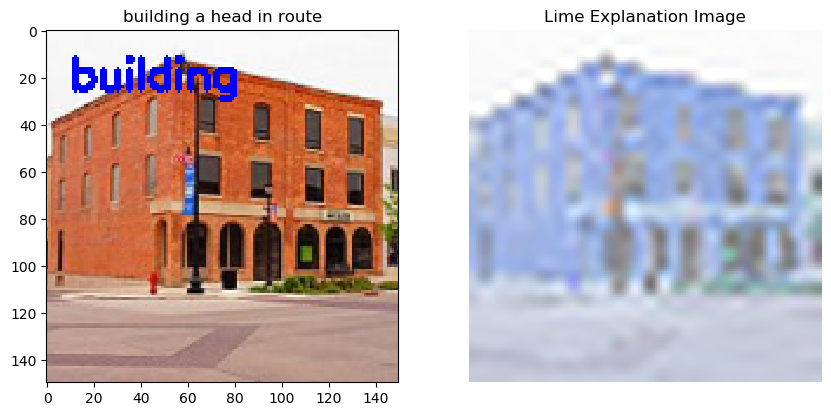

In [42]:
#call this function with image to predict route
predictRoute("testImages/2.jpg")

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


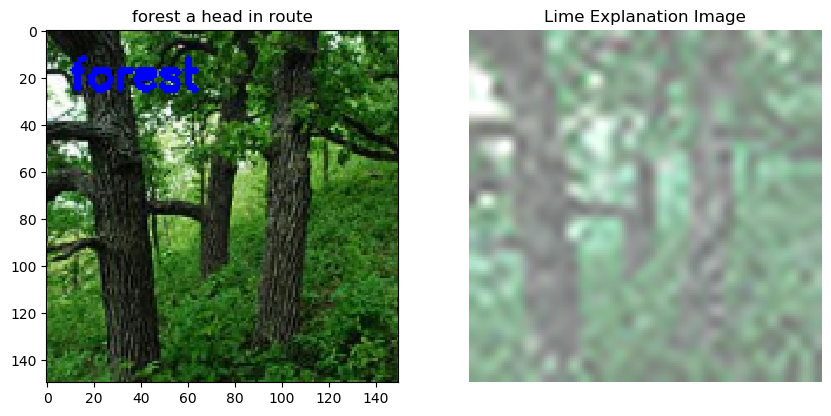

In [43]:
#call this function with image to predict route
predictRoute("testImages/4.jpg")

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


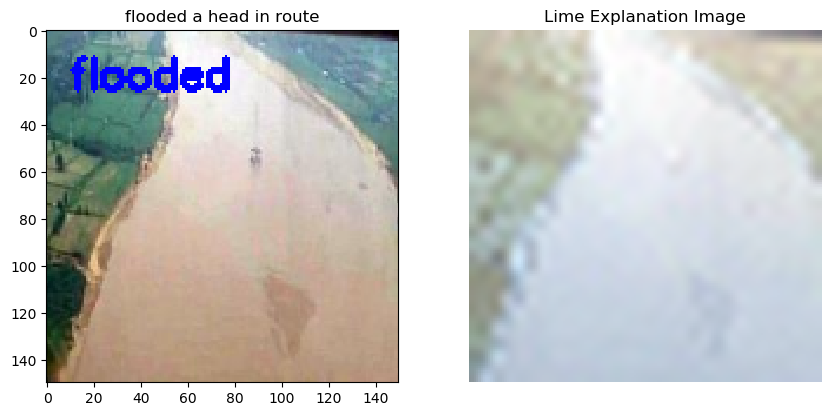

In [46]:
#call this function with image to predict route
predictRoute("testImages/6.jpg")